COMPD_CS["NAD83(2011) / UTM zone 6N + unknown",PROJCS["NAD83(2011) / UTM zone 6N",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-147],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]],VERT_CS["unknown",VERT_DATUM["unknown",2005],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related height",UP]]]
Kite
171 initial vertices
13 vertices after simplification
Prow
182 initial vertices
22 vertices after simplification
Core
278 initial vertices
22 vertices after simplification
Tail
257 initial vertices
27 vertices after simplification
Wedge
181 initial vertices
21 vertices after simp

/var/folders/k1/039pfytn6x7dgr4j_lhkvs9h0000gn/T/ipykernel_64562/4063032581.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{lbl/1000}' for lbl in ax.get_xticks()], size=12)
/var/folders/k1/039pfytn6x7dgr4j_lhkvs9h0000gn/T/ipykernel_64562/4063032581.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{lbl/1000}' for lbl in ax.get_yticks()], size=12)


,x_utm,y_utm,zone
0,436756.8956,6.779035e+06,Kite
1,436890.8280,6.779114e+06,Kite
2,437005.2748,6.779259e+06,Kite
3,437136.9737,6.779282e+06,Kite
4,437159.8900,6.779202e+06,Kite


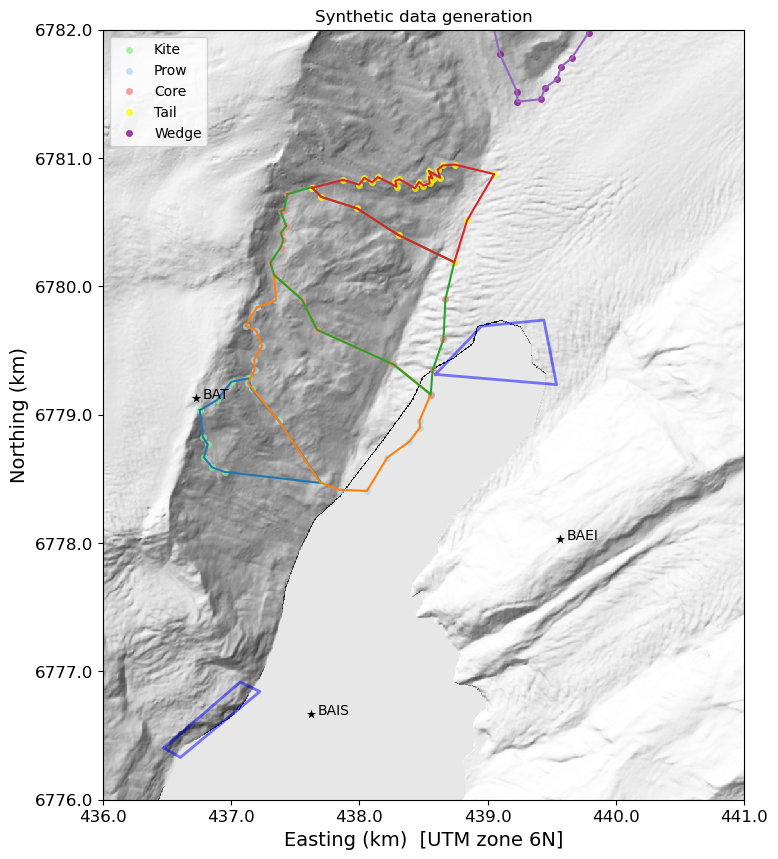

In [33]:
#src/infresnel
#Plot basemap, plot polygons,
import pyproj
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr
import utm
import shapely.geometry as geom
import geopandas as gpd
import pandas as pd
import matplotlib.patches as mpatches
np.random.seed(41)

def load_dem_basemap(dem_file, figsize=(10,10)):
    """open and clean dem, project to UTM"""
    dem = xr.open_dataarray(dem_file)
    # Clean DEM before going further
    dem = dem.squeeze(drop=True).rename('elevation')

    fig, ax = plt.subplots(figsize=figsize)
    hs = dem.copy()
    hs.data = mpl.colors.LightSource().hillshade(
        dem.data,
        dx=abs(dem.x.diff('x').mean().values),
        dy=abs(dem.y.diff('y').mean().values),
    )
    im = hs.plot.imshow(ax=ax, cmap='Greys_r', add_colorbar=False, add_labels=False)
    ax.set_aspect('equal')

    #ax.set_xlim(434000, 442000)
    #ax.set_ylim(6775000, 6783500)
    ax.set_xlim(436000, 441000)
    ax.set_ylim(6776000, 6782000)
    ax.set_xticklabels([f'{lbl/1000}' for lbl in ax.get_xticks()], size=12)
    ax.set_yticklabels([f'{lbl/1000}' for lbl in ax.get_yticks()], size=12)

    crs_wkt = dem.coords['spatial_ref'].attrs['crs_wkt'] # Extract the WKT of the CRS from the spatial_ref attribute
    utm_crs = pyproj.CRS.from_wkt(crs_wkt) # Create a CRS object from the WKT string
    #wgs84_proj = pyproj.CRS("EPSG:4326")  # WGS84 (latitude, longitude)
    #transformer = pyproj.Transformer.from_crs(wgs84_proj, utm_crs, always_xy=True) # Create the transformer for coordinate transformation
    
    utm_zone = utm_crs.utm_zone
    ax.set_ylabel(f'Northing (km)', size=14)
    ax.set_xlabel(f'Easting (km)  [UTM zone {utm_zone}]', size=14)
    

    return fig,ax, utm_zone#, transformer


dem_file = "data/modified_dem_5m.tif"
fig, ax, utm_zone = load_dem_basemap(dem_file)

# plot station coordinates:

site_locations = {'BAEI': (61.13218, -148.12206), 'BAIS':(61.11967, -148.15770), 'BAT':(61.14160, -148.17510)}
def plot_station_coords(ax, site_locations=site_locations):
    for name,ll in site_locations.items():
        x, y, zone_number, lat_band   = utm.from_latlon(ll[0], ll[1]) #This should really be using a pyproj transformation instead
        ax.scatter(x, y, marker='*', s=50, color='black', lw=0)
        ax.text(x+50, y, name)

plot_station_coords(ax)

def plot_polygon(coords, ax, color='red'):
    # Draw the polygon
    utm_coords = [utm.from_latlon(ll[0], ll[1])[:2] for ll in coords]
    #print(utm_coords)
    polygon = geom.Polygon(utm_coords)  # Create polygon from UTM coordinates
    x, y = polygon.exterior.xy  # Get the x and y coordinates of the polygon
    #print(x)
    #Plot the polygon on the basemap (in UTM coordinates)
    ax.plot(x, y, color=color, linewidth=2, alpha=0.5)
    return polygon #return the polygon object in utm coordinates
    

barry_poly_ll = [(61.14357, -148.14055),
                   (61.147, -148.134),
                   (61.14750, -148.125),
                   (61.143, -148.123),
                   (61.14357, -148.14055)]
cascade_poly_ll = [(61.11711, -148.17883),
                   (61.12181, -148.16802),
                   (61.12117, -148.16514),
                   (61.11646, -148.17647),
                   (61.11711, -148.17883)]

#ba_poly = plot_polygon(ba_poly_ll, ax=ax)
gl_poly = plot_polygon(barry_poly_ll, ax=ax, color='blue')
gl2_poly = plot_polygon(cascade_poly_ll, ax=ax, color='blue')

def load_kinematic_elements():
    # path to the .shp
    shp_path = "data/kinematic_elements/Kinematic_Elements.shp" #From coe et al. 2021
    gdf = gpd.read_file(shp_path)
    print(gdf.crs) #be somewhat cautious here. these are UTM coordinates but in Nad83, not WGS84. A transform is applied later. 
    #gdf = gdf.iloc[0:4] #drop wedge
    #re order
    order = ['Kite', 'Prow', 'Core', 'Tail', 'Wedge']
    gdf['Name'] = pd.Categorical(gdf['Name'], categories=order, ordered=True)
    gdf = gdf.sort_values('Name')
    # rescale to kms
    #gdf['geometry'] = gdf['geometry'].apply(lambda g: scale(g, xfact=1/1000, yfact=1/1000, origin=(0,0)))
    return gdf

geodf = load_kinematic_elements()

zcolors = ["lightgreen", "lightblue", "lightcoral", "yellow", "purple"]
zonesss = []
for i, row in enumerate(geodf.itertuples()):
    zone_poly = row.geometry
    print(row.Name)
    print(f"{len(zone_poly.exterior.coords)} initial vertices")
    simp = zone_poly.exterior.simplify(20)
    zone_pts = np.array(simp.coords)
    
    print(f"{zone_pts.shape[0]} vertices after simplification")
    npts = zone_pts.shape[0]
    #plot convex hull
    ax.plot(zone_pts[:,0], zone_pts[:,1])
    ax.scatter(zone_pts[:,0], zone_pts[:,1], marker='o', s=25, c=zcolors[i], alpha=0.75, lw=0, label=f"{row.Name}")
    if i==0:
        ba_pts = zone_pts
    else:
        ba_pts = np.append(ba_pts, zone_pts, axis=0)
    zonesss.extend(npts*[row.Name])

#create legend
ax.legend(loc='upper left')
ax.set_title('Synthetic data generation')
sdf = pd.DataFrame()
sdf['x_utm'] = ba_pts[:,0]
sdf['y_utm'] = ba_pts[:,1]
sdf['zone'] = zonesss
sdf.head()

In [34]:
# Using infresnel to calculate path lengths
# improvement 1 - use infresnel to calculate path lengths
# improvement 2 - also calculate sigma tau (?)
# then, save all data
# begin plotting and comparing with real data
import infresnel
import pandas as pd
import pyproj
import numpy as np



dem_file = "data/modified_dem_5m.tif"
utm_crs = 'EPSG:26909' #Nad83 / UTM 6N #crs of the dem
utm_crs2 = 'EPSG:32606' #WGS84 / UTM 6N 
utm_crs3 = 'EPSG:6335' #NAD83(2011) / UTM zone 6N #crs of the shape files for kinematic elements
ll_crs = 'EPSG:4326' # WGS84 / lat lon #target crs
trans1 = pyproj.Transformer.from_crs( "EPSG:6335","EPSG:4326", always_xy=True)

lat_list = [61.132675, 61.132085, 61.13173, 61.131875, 61.132405, 61.13218]
lon_list = [-148.1219, -148.12107, -148.121985, -148.122915, -148.12281, -148.12206]
elev_list = [591.8, 607.6, 597.6, 584.6, 582.0, 596.2]

stations = ['BAEI.01', 'BAEI.02', 'BAEI.03', 'BAEI.04', 'BAEI.05', 'BAEI.06', 'BAIS.01', 'BAIS.02', 'BAIS.03', 'BAIS.04', 'BATI.']
lat_list = [61.132675, 61.132085, 61.13173, 61.131875, 61.132405, 61.13218, 61.11962, 61.119775, 61.11939, 61.119575, 61.14172]
lon_list = [-148.1219, -148.12107, -148.121985, -148.122915, -148.12281, -148.12206, -148.158315, -148.157485, -148.1579, -148.157775, -148.175]
elev_list = [591.8, 607.6, 597.6, 584.6, 582.0, 596.2,     9.5, 9.5, 9.5, 9.5,     1034.4]

sdf['longitude'], sdf['latitude'] = trans1.transform(sdf['x_utm'], sdf['y_utm'])


for sta, lat, lon in zip(stations, lat_list, lon_list):
    direct_paths, diffracted_paths = infresnel.calculate_paths(lat, lon, sdf['latitude'], sdf['longitude'], dem_file)
    sdf[f'{sta}_direct_path'] = direct_paths
    sdf[f'{sta}_diffracted_path'] = diffracted_paths

# optional save intermediate step
#sdf.to_csv('data/synthetic_dataset_convex_hull.csv', index=False)

Loading and projecting DEM...
Done

DEM spacing = 5.00 m -> profile spacing = 2.50 m

Checking that DEM contains source and receivers...
Done

Fitting spline to DEM...
Done

Computing 105 paths...


  0% |          | 0/105 paths 

Done
Loading and projecting DEM...
Done

DEM spacing = 5.00 m -> profile spacing = 2.50 m

Checking that DEM contains source and receivers...
Done

Fitting spline to DEM...
Done

Computing 105 paths...


  0% |          | 0/105 paths 

Done
Loading and projecting DEM...
Done

DEM spacing = 5.00 m -> profile spacing = 2.50 m

Checking that DEM contains source and receivers...
Done

Fitting spline to DEM...
Done

Computing 105 paths...


...

Done
Loading and projecting DEM...
Done

DEM spacing = 5.00 m -> profile spacing = 2.50 m

Checking that DEM contains source and receivers...
Done

Fitting spline to DEM...
Done

Computing 105 paths...


  0% |          | 0/105 paths 

Done
Loading and projecting DEM...
Done

DEM spacing = 5.00 m -> profile spacing = 2.50 m

Checking that DEM contains source and receivers...
Done

Fitting spline to DEM...
Done

Computing 105 paths...


  0% |          | 0/105 paths 

Done


In [37]:
#Calculating arrival times, and velocity and azimuth using lts underlying code

import numpy as np
import pandas as pd
import pyproj
from obspy.geodetics import calc_vincenty_inverse

# ----------------------------
# cloned LTS functions
# ----------------------------

def getrij(latlist, lonlist):
        r""" Calculate element locations (r_ij) from latitude and longitude.

        Return the projected geographic positions
        in X-Y (Cartesian) coordinates. Points are calculated
        with the Vincenty inverse and will have a zero-mean.

        Args:
            latlist (list): A list of latitude points.
            lonlist (list): A list of longitude points.

        Returns:
            (array):
            ``rij``: A NumPy array with the first row corresponding to
            cartesian "X" - coordinates and the second row
            corresponding to cartesian "Y" - coordinates, in units of km.
        """
        nchans = len(latlist)
        # Pre-allocate "x" and "y" arrays.
        xnew = np.zeros((nchans, ))
        ynew = np.zeros((nchans, ))

        for jj in range(1, nchans):
            # Obspy defaults to the WGS84 ellipsoid.
            delta, az, _ = calc_vincenty_inverse(
                latlist[0], lonlist[0], latlist[jj], lonlist[jj])
            # Convert azimuth to degrees from North
            az = (450 - az) % 360
            xnew[jj] = delta/1000 * np.cos(az*np.pi/180)
            ynew[jj] = delta/1000 * np.sin(az*np.pi/180)

        # Remove the mean.
        xnew -= np.mean(xnew)
        ynew -= np.mean(ynew)

        rij = np.array([xnew.tolist(), ynew.tolist()])

        return rij

def compute_tau(arrival_times, idx_pair):
    return np.array([arrival_times[j] - arrival_times[i] for (i, j) in idx_pair]) #Note this was flipped initially. This is correct now. 


def build_coarray(rij, idx_pair):
    xij = (
        rij[:, np.array([ii for ii, _ in idx_pair])]
        - rij[:, np.array([jj for _, jj in idx_pair])]
    )
    return xij.T


def standardize_xij(xij):
    xij_std = np.zeros_like(xij)
    xij_mad = np.zeros(2)
    for d in range(2):
        xij_mad[d] = 1.4826 * np.median(np.abs(xij[:, d]))
        xij_std[:, d] = xij[:, d] / xij_mad[d]
    return xij_std, xij_mad


def solve_beam(tau, time_delay_mad, xij, xij_std, xij_mad):
    q_xij, r_xij = np.linalg.qr(xij_std)

    y_var = (tau / time_delay_mad).reshape(-1, 1)
    qt = q_xij.conj().T @ y_var
    z_final = np.linalg.lstsq(r_xij, qt, rcond=None)[0]

    for d in range(2):
        z_final[d, 0] *= time_delay_mad / xij_mad[d]

    sx, sy = z_final[:, 0]
    velocity = 1.0 / np.linalg.norm(z_final, ord=2)
    azimuth = (np.arctan2(sx, sy) * 180 / np.pi - 360) % 360

    # Sigma_tau calculation for single time step (Szuberla et al. 2006)
    co_array_num = tau.size
    dimension_number = 2
    residuals = tau.reshape(-1, 1) - (xij @ z_final)
    sigma_tau = np.sqrt(
        (tau.reshape(1, -1) @ residuals) / (co_array_num - dimension_number)
    )[0, 0]

    return velocity, azimuth, sigma_tau


# ----------------------------
# Load data if using
#sdf = pd.read_csv('data/synthetic_dataset_convex_hull.csv')

##BAEI
lat_list = [61.132675, 61.132085, 61.13173, 61.131875, 61.132405, 61.13218]
lon_list = [-148.1219, -148.12107, -148.121985, -148.122915, -148.12281, -148.12206]
elev_list = [591.8, 607.6, 597.6, 584.6, 582.0, 596.2]
##BAIS
#lat_list = [ 61.11962, 61.119775, 61.11939, 61.119575,]
#lon_list = [-148.158315, -148.157485, -148.1579, -148.157775]
#elev_list = [ 9.5, 9.5, 9.5, 9.5,]


trans = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32606", always_xy=True) #Transform lat lon to WGS84 UTM 6N
baei_array = np.vstack([trans.transform(lon_list, lat_list), elev_list])

C = 334.337  #np.sqrt(1.4 * 8.31432 * (5 + 273.15) / 0.0289644 ) # calcualted from eq 10 Edwards et al
print(C)

rij = getrij(lat_list, lon_list)
print(rij)
#rij = np.array(
#    [
#        [0.01203378, 0.05675638, 0.0074537, -0.04265749, -0.03699895, 0.00341258],
#        [0.05757267, -0.00817152, -0.04772992, -0.03157196, 0.02748655, 0.00241418],
#    ]) #BAEI RIJ

nchans = 6
idx_pair = [(ii, jj) for ii in range(nchans - 1) for jj in range(ii + 1, nchans)]

#prepare to drop stations
drop_station = None #python indexing, so drop_station=0 means station 01 will be dropped from the calculations
if drop_station is not None:
    print(f"STATION 0{drop_station+1} is being dropped")
    pair_mask = np.array([(ii != drop_station) and (jj != drop_station) for (ii, jj) in idx_pair])

xij = build_coarray(rij, idx_pair)
if drop_station is not None:
    xij = xij[pair_mask]
xij_std, xij_mad = standardize_xij(xij)

# ----------------------------
# Loop over sources
velocities = []
azimuths = []
sigma_taus = []
for _, row in sdf.iterrows():
    
    path_calc = 'diffracted_path'
    path_rows = [f'BAEI.{i:02}_{path_calc}' for i in range(1,nchans+1)] #or change to BAIS
    distances = row[path_rows].to_numpy()
    arrival_times = distances / C
    tau = compute_tau(arrival_times, idx_pair)
    if drop_station is not None:
        tau = tau[pair_mask]
    
    # NOTE - perhaps tau should be rounded to nearest hundredth of a second?
    # Here you can choose whether or not to do so. 
    #tau = np.round(tau, 2)

    time_delay_mad = 1.4826 * np.median(np.abs(tau))

    velocity, azimuth, sigma_tau = solve_beam(
        tau, time_delay_mad, xij, xij_std, xij_mad
    )

    velocities.append(velocity)
    azimuths.append(azimuth)
    sigma_taus.append(sigma_tau)

sdf["lts_velocity_at5C"] = velocities
sdf["lts_azimuth"] = azimuths
sdf['sigma_tau'] = sigma_taus
sdf['apparent_over_true_velocity'] = sdf['lts_velocity_at5C']*1000 / C
print(sdf.shape)
sdf.head()
#Save these results, useful for viewing range of velocity, azimuth, and sigma_tau values expected
sdf.to_csv("data/baei_synthetic_results.csv", index=False)

334.337
[[ 0.01203378  0.05675638  0.0074537  -0.04265749 -0.03699895  0.00341258]
 [ 0.05757267 -0.00817152 -0.04772992 -0.03157196  0.02748655  0.00241418]]
(105, 31)


In [38]:
#Save to geodataframe, with polygon defined in backazimuth (degrees) and velocity (km/s) 
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon

rows = []

for zone in sdf['zone'].unique():
    subdf = sdf.loc[sdf['zone'] == zone]

    coords = np.column_stack(
        (subdf['lts_azimuth'].to_numpy(),
         subdf['lts_velocity_at5C'].to_numpy())
    )

    # ensure polygon is closed
    if not np.array_equal(coords[0], coords[-1]):
        coords = np.vstack([coords, coords[0]])

    poly = Polygon(coords)

    rows.append({"zone": zone, "polygon": poly})

gdf = gpd.GeoDataFrame(rows, geometry="polygon")

gfile = "data/BAEI_landslide_AzVel.gpkg"
gdf.to_file(gfile, driver="GPKG")
gdf.head()


/Users/che/miniconda3/envs/infresnel/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


,zone,polygon
0,Kite,"POLYGON ((289.438 0.348, 292.023 0.347, 295.67..."
1,Prow,"POLYGON ((307.81 0.346, 310.03 0.342, 313.074 ..."
2,Core,"POLYGON ((322.5 0.347, 325.698 0.346, 325.967 ..."
3,Tail,"POLYGON ((325.698 0.346, 329.194 0.344, 330.60..."
4,Wedge,"POLYGON ((0.798 0.333, 1.483 0.331, 359.146 0...."


/var/folders/k1/039pfytn6x7dgr4j_lhkvs9h0000gn/T/ipykernel_64562/1450044045.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{lbl/1000}' for lbl in ax.get_xticks()],) #size=12)
/var/folders/k1/039pfytn6x7dgr4j_lhkvs9h0000gn/T/ipykernel_64562/1450044045.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{lbl/1000}' for lbl in ax.get_yticks()], )#size=12)


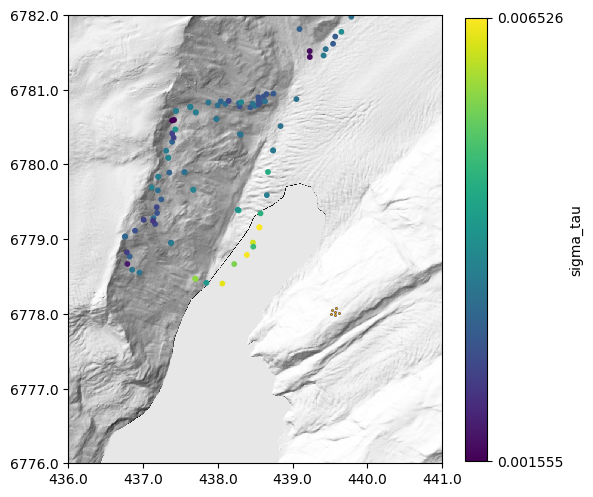

In [26]:
#plot results
import pyproj
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import utm
import shapely.geometry as geom
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.patches as mpatches
np.random.seed(42) #SET SEED

def load_dem_basemap(dem_file, figsize=(10,10)):
    """open and clean dem, project to UTM"""
    dem = xr.open_dataarray(dem_file)
    # Clean DEM before going further
    dem = dem.squeeze(drop=True).rename('elevation')

    fig, ax = plt.subplots(figsize=figsize)
    hs = dem.copy()
    hs.data = mpl.colors.LightSource().hillshade(
        dem.data,
        dx=abs(dem.x.diff('x').mean().values),
        dy=abs(dem.y.diff('y').mean().values),
    )
    im = hs.plot.imshow(ax=ax, cmap='Greys_r', add_colorbar=False, add_labels=False)
    ax.set_aspect('equal')

    #ax.set_xlim(434000, 442000)
    #ax.set_ylim(6775000, 6783500)
    ax.set_xlim(436000, 441000)
    ax.set_ylim(6776000, 6782000)
    ax.set_xticklabels([f'{lbl/1000}' for lbl in ax.get_xticks()],) #size=12)
    ax.set_yticklabels([f'{lbl/1000}' for lbl in ax.get_yticks()], )#size=12)

    crs_wkt = dem.coords['spatial_ref'].attrs['crs_wkt'] # Extract the WKT of the CRS from the spatial_ref attribute
    utm_crs = pyproj.CRS.from_wkt(crs_wkt) # Create a CRS object from the WKT string
    #wgs84_proj = pyproj.CRS("EPSG:4326")  # WGS84 (latitude, longitude)
    #transformer = pyproj.Transformer.from_crs(wgs84_proj, utm_crs, always_xy=True) # Create the transformer for coordinate transformation
    
    utm_zone = utm_crs.utm_zone
    #ax.set_ylabel(f'Northing (km)', size=14)
    #ax.set_xlabel(f'Easting (km)  [UTM zone {utm_zone}]', size=14)
    

    return fig,ax, utm_zone#, transformer

dem_file = "data/modified_dem_5m.tif"
fig, ax, utm_zone = load_dem_basemap(dem_file, figsize=(6,6))

sdf = pd.read_csv("data/baei_synthetic_results.csv")
cols = ['sigma_tau',"lts_azimuth", "z_meters", "lts_velocity_at5C", "baei_6_diffracted_path", 'baei_az', 'baei_elevation_angle']
cii=0 #USE THIS to select which COL from the list to PLOT
pts = ax.scatter(sdf['x_utm'], sdf['y_utm'], c=sdf[cols[cii]], s=10)

fig.colorbar(pts, label=cols[cii], ticks=[sdf[cols[cii]].min(), 0,sdf[cols[cii]].max()], shrink=0.8 )

def plot_station_coords(ax, site_locations, marker='*', color='red', text=None, s=50, label=None, ec='k', lw=0.3):
    for name,ll in site_locations.items():
        x, y, zone_number, lat_band   = utm.from_latlon(ll[0], ll[1])
        ax.scatter(x, y, marker=marker, s=s, color=color,label=label, ec=ec, lw=lw)
        if text is not None:
            ax.text(x+50, y, name)
        #return label



baei_stations = {'AV.BAEI.01.HDF': (61.132675, -148.1219), 'AV.BAEI.02.HDF': (61.132085, -148.12107), 'AV.BAEI.03.HDF': (61.13173, -148.121985), 
                 'AV.BAEI.04.HDF': (61.131875, -148.122915), 'AV.BAEI.05.HDF': (61.132405, -148.12281), 'AV.BAEI.06.HDF': (61.13218, -148.12206)}
plot_station_coords(ax, baei_stations, marker='.', color='orange', s=10, label='Infrasound')
plt.tight_layout()

swarm.csv and swarm_triggers.csv: These files can be read by Swarm v2.8.5+ using the "tagging" feature to annotate the interactive helicorders. It marks each repeating event with a label that has the groupname and the family it belongs to (so for the default run, Family 1 would be labeled as 'default1'). The station listed is the one referenced by printsta in the configuration, and can be changed using global find/replace in a text editor to change which station or channel the tags should appear on. Colors can be chosen for families or types of interest by adding lines to the EventClassifications.config file in the Swarm folder. For example, adding the line:

default1, #ffff00

changes the appearance of members of the default1 family to be yellow to stand out against the default red-orange of the rest of the catalog. The swarm_triggers.csv file contains all events in swarm.csv but at the times that they originally triggered (i.e., before they were aligned).  